# Exploratory Data Analysis - servir_jobs_transformed.db
Basic exploration: shape, nulls, variables, descriptive statistics

In [47]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Absolute path - works from anywhere
project_root = Path("/Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis")
db_path = project_root / "servir" / "data" / "transformed" / "servir_jobs_transformed.db"

print(f"Project root: {project_root}")
print(f"DB path: {db_path}")
print(f"DB exists: {db_path.exists()}")

# Load data
print("Loading transformed data...")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM transformed_jobs", conn)
conn.close()

print(f"✓ Loaded {len(df):,} job postings")

Project root: /Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis
DB path: /Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis/servir/data/transformed/servir_jobs_transformed.db
DB exists: True
Loading transformed data...
✓ Loaded 21,575 job postings


=============================================================================
## 1. BASIC SHAPE AND STRUCTURE
=============================================================================

In [48]:
print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Column types
print("\nColumn types:")
print(df.dtypes.value_counts())


Rows: 21,575
Columns: 79

Memory usage: 51.91 MB

Column types:
float64    48
object     22
int64       9
Name: count, dtype: int64


=============================================================================
## 2. VARIABLE INVENTORY
=============================================================================

In [49]:
print("\n" + "="*80)
print("2. AVAILABLE VARIABLES")
print("="*80)

# Group columns by category
original_cols = ['id', 'posting_unique_id', 'job_title', 'institution', 
                 'posting_start_date', 'posting_end_date', 'salary_amount',
                 'number_of_vacancies', 'contract_type', 'experience_requirements',
                 'academic_profile', 'specialization', 'knowledge', 'competencies']

matching_cols = [c for c in df.columns if 'isco' in c.lower() or 'ejecutora' in c.lower() 
                 or 'programa' in c.lower() or 'sector' in c.lower() or 'pliego' in c.lower()]

parsed_cols = [c for c in df.columns if 'years' in c.lower() or 'required' in c.lower() 
               or 'regime' in c.lower() or 'temporal' in c.lower() or 'thesis' in c.lower()]

topic_cols = [c for c in df.columns if 'topic' in c.lower()]

print(f"\nOriginal columns: {len([c for c in original_cols if c in df.columns])}")
print(f"Matching columns (ISCO, MEF, CLASIFICADOR): {len(matching_cols)}")
print(f"Parsed columns (structured extraction): {len(parsed_cols)}")
print(f"Topic columns (LDA): {len(topic_cols)}")


2. AVAILABLE VARIABLES

Original columns: 14
Matching columns (ISCO, MEF, CLASIFICADOR): 8
Parsed columns (structured extraction): 7
Topic columns (LDA): 45


=============================================================================
## 3. NULL ANALYSIS
=============================================================================


Columns with missing data (>0%):
                   Column  Missing  Percent
experience_specific_years    18448     85.5
 experience_general_years    16621     77.0
   campo_detallado_codigo    14447     67.0
          programa_codigo    14447     67.0
                isco_code     4311     20.0
         ejecutora_nombre     3831     17.8
                ejecutora     3831     17.8
                 sec_ejec     3831     17.8
                   pliego     3831     17.8
                   sector     3831     17.8
           nivel_gobierno     3831     17.8


<Figure size 1200x600 with 0 Axes>

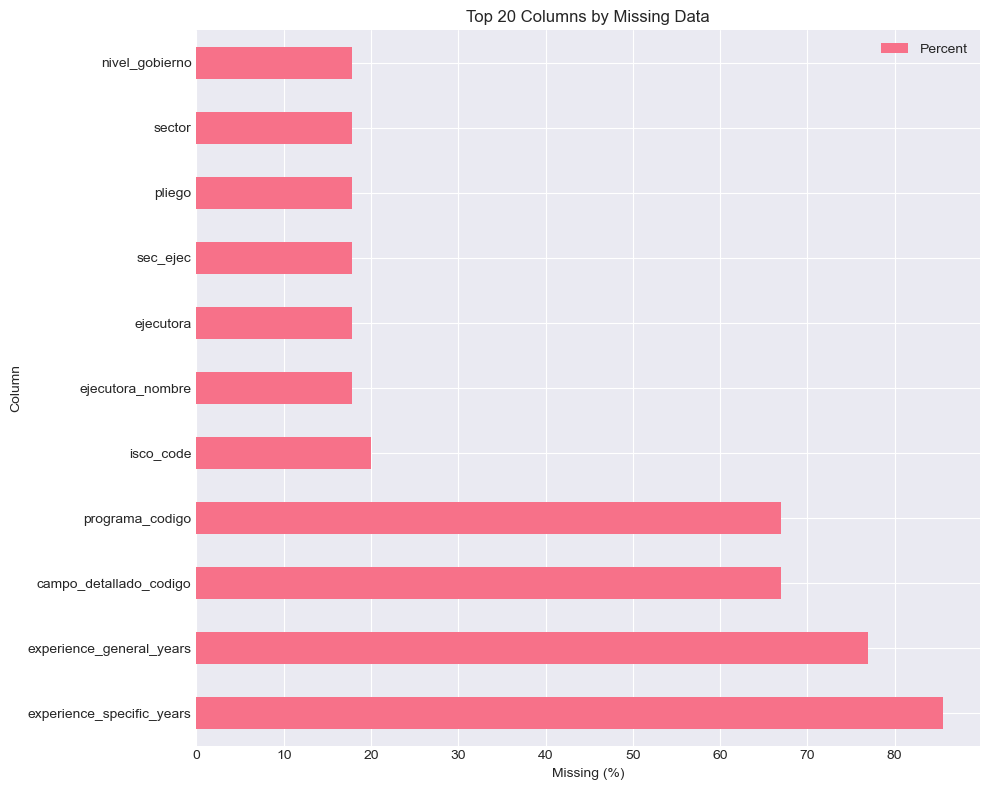

In [50]:
null_counts = df.isnull().sum()
null_pcts = (null_counts / len(df) * 100).round(1)

print("\nColumns with missing data (>0%):")
missing_df = pd.DataFrame({
    'Column': null_counts[null_counts > 0].index,
    'Missing': null_counts[null_counts > 0].values,
    'Percent': null_pcts[null_counts > 0].values
}).sort_values('Percent', ascending=False)

print(missing_df.to_string(index=False))

# Visualize missingness
plt.figure(figsize=(12, 6))
missing_df.head(20).plot(x='Column', y='Percent', kind='barh', figsize=(10, 8))
plt.xlabel('Missing (%)')
plt.title('Top 20 Columns by Missing Data')
plt.tight_layout()
plt.savefig(project_root / "servir" / "data" / "analysed" / "output" / "missing_data.png", dpi=300, bbox_inches='tight')
plt.show()

=============================================================================
## 4. DESCRIPTIVE STATISTICS - NUMERIC VARIABLES
=============================================================================



Numeric variables: 57

Key numeric variables summary:
       salary_amount  number_of_vacancies  experience_general_years  \
count   21575.000000         21575.000000               4954.000000   
mean     3607.285695             2.529316                  3.667945   
std      9002.477435            59.295949                113.912138   
min         1.000000             1.000000                  0.000000   
25%      2000.000000             1.000000                  1.000000   
50%      2900.000000             1.000000                  2.000000   
75%      4000.000000             1.000000                  3.000000   
max    636419.000000          6624.000000               8019.000000   

       experience_specific_years  
count                3127.000000  
mean                    4.032939  
std                   143.381223  
min                     0.000000  
25%                     1.000000  
50%                     1.000000  
75%                     2.000000  
max                  8019

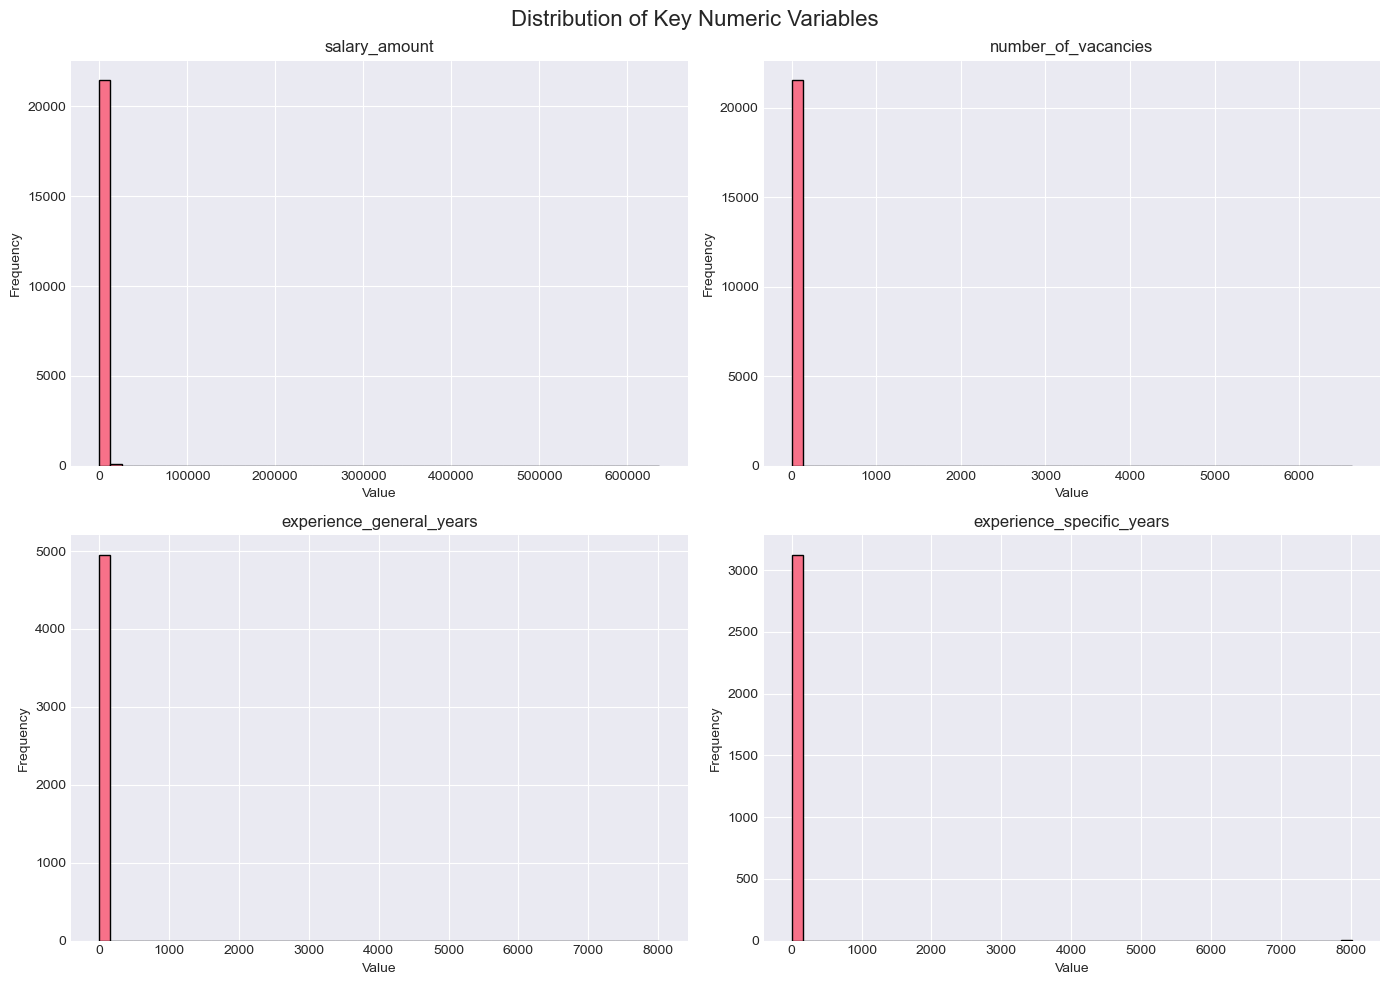

In [51]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nNumeric variables: {len(numeric_cols)}")

# Key numeric variables (non-topic)
key_numeric = ['salary_amount', 'number_of_vacancies', 
               'experience_general_years', 'experience_specific_years']

print("\nKey numeric variables summary:")
print(df[key_numeric].describe())

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Numeric Variables', fontsize=16)

for idx, col in enumerate(key_numeric):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=50, ax=ax, edgecolor='black')
    ax.set_title(f'{col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(project_root / "servir" / "data" / "analysed" / "output" / "numeric_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

In [52]:
print("=== SALARY OUTLIERS ===")
print(df[df['salary_amount'] > 50000][['job_title', 'institution', 'salary_amount']].sort_values('salary_amount', ascending=False).head(10))

print("\n=== VACANCIES OUTLIERS ===")
print(df[df['number_of_vacancies'] > 100][['job_title', 'institution', 'number_of_vacancies']].sort_values('number_of_vacancies', ascending=False).head(10))

print("\n=== EXPERIENCE OUTLIERS ===")
print(df[df['experience_general_years'] > 50][['job_title', 'institution', 'experience_general_years']].sort_values('experience_general_years', ascending=False).head(10))

print("=== SALARY DISTRIBUTION (plausible range) ===")
print(f"Salaries above 30,000: {(df['salary_amount'] > 30000).sum()} rows")
print(f"Salaries above 50,000: {(df['salary_amount'] > 50000).sum()} rows")
print(f"Salaries below 100: {(df['salary_amount'] < 100).sum()} rows")

print("\n=== RAW SALARY VALUES FOR TOP OUTLIERS ===")
# Check posting_unique_id so we can trace back to raw/cleaned DB
print(df[df['salary_amount'] > 50000][['posting_unique_id', 'job_title', 'institution', 'salary_amount']].to_string())

=== SALARY OUTLIERS ===
                                               job_title  \
16240                               ANALISTA PROGRAMADOR   
5134     ESPECIALISTA EN SEGURIDAD Y SALUD EN EL TRABAJO   
5133   ESPECIALISTA EN CAPACITACION Y DESARROLLO DE P...   
5486                     ESPECIALISTA EN SERVICIO SOCIAL   
3610                      ESPECIALISTA EN ABASTECIMIENTO   
12628                                     ABOGADO JUNIOR   
14248                                      PSICOLOGA JEC   
10556                               AUXILIAR ASISTENCIAL   
10555                               AUXILIAR ASISTENCIAL   
9183   ASESORAMIENTO LEGAL A LAS COMISIONES DE PROCES...   

                                             institution  salary_amount  
16240             PROGRAMA NACIONAL DE SANEAMIENTO RURAL      636419.00  
5134                UNIDAD DE GESTION EDUCATIVA LOCAL 07      576419.00  
5133                UNIDAD DE GESTION EDUCATIVA LOCAL 07      526419.00  
5486               

In [53]:
lower_bound = 1025  # Peru minimum wage

p99 = df['salary_amount'].quantile(0.99)
p995 = df['salary_amount'].quantile(0.995)

print(f"Peru minimum wage: S/. {lower_bound:,.0f}")
print(f"99th percentile:   S/. {p99:,.2f}")
print(f"99.5th percentile: S/. {p995:,.2f}")
print(f"\nRows below minimum wage: {(df['salary_amount'] < lower_bound).sum()}")
print(f"Rows above p99:          {(df['salary_amount'] > p99).sum()}")
print(f"Rows above p99.5:        {(df['salary_amount'] > p995).sum()}")

# Preview what gets excluded at each threshold
print(f"\nSalary range after filtering (min wage to p99):")
clean = df[(df['salary_amount'] >= lower_bound) & (df['salary_amount'] <= p99)]
print(clean['salary_amount'].describe())

Peru minimum wage: S/. 1,025
99th percentile:   S/. 11,308.39
99.5th percentile: S/. 12,364.19

Rows below minimum wage: 291
Rows above p99:          215
Rows above p99.5:        105

Salary range after filtering (min wage to p99):
count    21069.000000
mean      3367.476949
std       1864.986085
min       1025.000000
25%       2050.000000
50%       2900.000000
75%       3964.190000
max      11308.390000
Name: salary_amount, dtype: float64


In [54]:
SALARY_MIN = 1130
SALARY_MAX = 15600

df['salary_flag'] = 'ok'
df.loc[df['salary_amount'] < SALARY_MIN, 'salary_flag'] = 'implausible_low'
df.loc[df['salary_amount'] > SALARY_MAX, 'salary_flag'] = 'implausible_high'

print(f"Salary bounds: S/. {SALARY_MIN:,} – S/. {SALARY_MAX:,}")
print(f"\nFlag counts:")
print(df['salary_flag'].value_counts())
print(f"Excluded: {(df['salary_flag'] != 'ok').sum()} rows ({(df['salary_flag'] != 'ok').mean()*100:.1f}%)")

df_salary = df[df['salary_flag'] == 'ok'].copy()
print(f"\nWorking salary dataset: {len(df_salary):,} rows")
print(df_salary['salary_amount'].describe())

Salary bounds: S/. 1,130 – S/. 15,600

Flag counts:
salary_flag
ok                  21200
implausible_low       354
implausible_high       21
Name: count, dtype: int64
Excluded: 375 rows (1.7%)

Working salary dataset: 21,200 rows
count    21200.000000
mean      3459.097156
std       2056.154214
min       1130.000000
25%       2064.190000
50%       2900.000000
75%       4000.000000
max      15600.000000
Name: salary_amount, dtype: float64


In [55]:
low = df[df['salary_flag'] == 'implausible_low'][['posting_unique_id', 'job_title', 'institution', 'salary_amount']]
print(f"Total: {len(low)}")
print(low.sort_values('salary_amount').head(20).to_string())
print("\nSalary distribution of low outliers:")
print(low['salary_amount'].describe())

Total: 354
       posting_unique_id                                                              job_title                               institution  salary_amount
17978             768436  EJECUTIVO / JEFE DE LA OFICINA DE GESTIÓN NTEGRAL DE RESIDUOS SÓLIDOS        MUNICIPALIDAD PROVINCIAL DE SIHUAS            1.0
20384             765717           ESPECIALISTA EN DESARROLLO ECONÓMICO Y PROMOCION EMPRESARIAL    MUNICIPALIDAD PROVINCIAL DE LAURICOCHA            1.0
19317             764598                                               ASISTENTE ADMINISTRATIVO      MUNICIPALIDAD DISTRITAL DE RIO NEGRO            1.0
15933             766121                                              AUXILIAR DE NUTRICIÓN SAB  UNIVERSIDAD NACIONAL DE SAN CRISTOBAL DH            1.0
15935             766113                                            AUXILIAR ADMINISTRATIVO SAB  UNIVERSIDAD NACIONAL DE SAN CRISTOBAL DH            1.0
15934             766117                                            AUX

=============================================================================
## 5. CATEGORICAL VARIABLES
=============================================================================

In [56]:
categorical_vars = ['contract_regime', 'contract_temporal_nature', 
                    'nivel_gobierno', 'sector_public_required', 
                    'sector_private_required', 'thesis_required']

for var in categorical_vars:
    if var in df.columns:
        print(f"\n{var}:")
        print(df[var].value_counts())


contract_regime:
contract_regime
D.LEG 1057    17328
D.LEG 276      2217
D.LEG 728      1695
LEY 30220       234
LEY 30057       101
Name: count, dtype: int64

contract_temporal_nature:
contract_temporal_nature
TEMPORARY    17237
PERMANENT     4338
Name: count, dtype: int64

nivel_gobierno:
nivel_gobierno
M    9749
E    7149
R     846
Name: count, dtype: int64

sector_public_required:
sector_public_required
1    14361
0     7214
Name: count, dtype: int64

sector_private_required:
sector_private_required
1    11745
0     9830
Name: count, dtype: int64

thesis_required:
thesis_required
0    18574
1     3001
Name: count, dtype: int64


=============================================================================
## 6. MATCHING COVERAGE
=============================================================================

In [57]:
coverage_metrics = {
    'ISCO Code': df['isco_code'].notna().sum(),
    'MEF Institution': df['ejecutora'].notna().sum(),
    'Academic Program': df['programa_codigo'].notna().sum(),
    'Full Match (all 3)': ((df['isco_code'].notna()) & 
                           (df['ejecutora'].notna()) & 
                           (df['programa_codigo'].notna())).sum()
}

coverage_df = pd.DataFrame({
    'Metric': coverage_metrics.keys(),
    'Count': coverage_metrics.values(),
    'Percent': [v/len(df)*100 for v in coverage_metrics.values()]
})

print("\nMatching Coverage:")
print(coverage_df.to_string(index=False))


Matching Coverage:
            Metric  Count   Percent
         ISCO Code  17264 80.018540
   MEF Institution  17744 82.243337
  Academic Program   7128 33.038239
Full Match (all 3)   6718 31.137891


=============================================================================
## 7. SAVE SUMMARY REPORT
=============================================================================

In [58]:
output_dir = project_root / "servir" / "data" / "analysed" / "output"
output_dir.mkdir(parents=True, exist_ok=True)
(output_dir / "figures").mkdir(exist_ok=True)

# Save summary statistics
with open(output_dir / "eda_summary.txt", 'w') as f:
    f.write("SERVIR JOBS TRANSFORMED - EXPLORATORY DATA ANALYSIS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
    f.write(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n\n")
    f.write("Matching Coverage:\n")
    f.write(coverage_df.to_string(index=False))
    f.write("\n\nMissing Data (top 10):\n")
    f.write(missing_df.head(10).to_string(index=False))

print(f"✓ Summary saved to: {output_dir / 'eda_summary.txt'}")
print(f"✓ Figures saved to: {output_dir / 'figures/'}")

✓ Summary saved to: /Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis/servir/data/analysed/output/eda_summary.txt
✓ Figures saved to: /Users/francosebastiani/Documents/GitHub/Peruvian-Civil-Service-Hiring-Patterns-Analysis/servir/data/analysed/output/figures


Date range:
  Earliest: 2025-12-12
  Latest:   2026-04-03
  Span:     5 months

Monthly posting volume:
year_month  count year_month_dt
   2025-12   2534    2025-12-01
   2026-01   3131    2026-01-01
   2026-02   7270    2026-02-01
   2026-03   8235    2026-03-01
   2026-04    405    2026-04-01


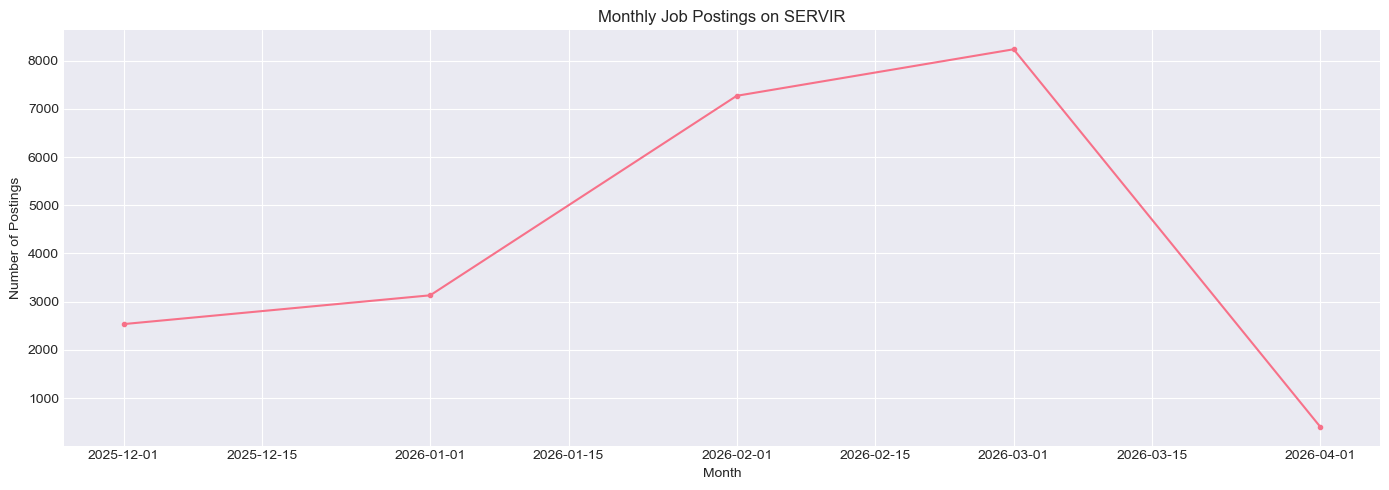

In [59]:
# ============================================================
# 8. POSTING LANDSCAPE
# ============================================================

# 8.1 Posting volume over time

df['posting_start_date'] = pd.to_datetime(df['posting_start_date'])
df['year_month'] = df['posting_start_date'].dt.to_period('M')

monthly_postings = df.groupby('year_month').size().reset_index(name='count')
monthly_postings['year_month_dt'] = monthly_postings['year_month'].dt.to_timestamp()

print("Date range:")
print(f"  Earliest: {df['posting_start_date'].min().date()}")
print(f"  Latest:   {df['posting_start_date'].max().date()}")
print(f"  Span:     {df['posting_start_date'].dt.to_period('M').nunique()} months")
print(f"\nMonthly posting volume:")
print(monthly_postings.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_postings['year_month_dt'], monthly_postings['count'], marker='o', linewidth=1.5, markersize=3)
ax.set_title('Monthly Job Postings on SERVIR')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Postings')
plt.tight_layout()
plt.savefig(output_dir / "figures" / "postings_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

In [60]:
repetition = (df.groupby(['institution', 'job_title'])
               .size()
               .reset_index(name='count')
               .sort_values('count', ascending=False))

print("Job title repetitions per institution:")
print(repetition['count'].describe())
print(f"\nInstitution-job pairs appearing more than once: {(repetition['count'] > 1).sum()}")
print(f"Institution-job pairs appearing more than 3x:   {(repetition['count'] > 3).sum()}")
print(f"\nTop 20 most repeated:")
print(repetition.head(20).to_string(index=False))

Job title repetitions per institution:
count    15272.000000
mean         1.412716
std          3.015812
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        245.000000
Name: count, dtype: float64

Institution-job pairs appearing more than once: 2288
Institution-job pairs appearing more than 3x:   526

Top 20 most repeated:
                                       institution                                                         job_title  count
REGISTRO NACIONAL DE IDENTIFICACIÓN Y ESTADO CIVIL                                               ASISTENTE REGISTRAL    245
               MINISTERIO PUBLICO-GERENCIA GENERAL                                       ASISTENTE EN FUNCIÓN FISCAL    122
               MINISTERIO PUBLICO-GERENCIA GENERAL                                          ASISTENTE ADMINISTRATIVO     83
                                    PODER JUDICIAL                                               SECRETARIO JUDICIAL     64
        

In [61]:
# How many unique institutions and job titles do we have?
print(f"Unique institutions: {df['institution'].nunique():,}")
print(f"Unique job titles:   {df['job_title'].nunique():,}")
print(f"Unique ISCO codes:   {df['isco_code'].nunique()}")

Unique institutions: 1,044
Unique job titles:   9,463
Unique ISCO codes:   403


In [62]:
# How many postings per ISCO code?
isco_dist = (df[df['isco_code'].notna()]
             .groupby('isco_code')
             .agg(
                 postings=('posting_unique_id', 'count'),
                 institutions=('institution', 'nunique'),
                 avg_salary=('salary_amount', 'mean')
             )
             .sort_values('postings', ascending=False)
             .reset_index())

print(f"ISCO codes with 10+ postings:  {(isco_dist['postings'] >= 10).sum()}")
print(f"ISCO codes with 50+ postings:  {(isco_dist['postings'] >= 50).sum()}")
print(f"ISCO codes with 100+ postings: {(isco_dist['postings'] >= 100).sum()}")
print(f"\nTop 20 ISCO codes by posting volume:")
print(isco_dist.head(20).to_string(index=False))

ISCO codes with 10+ postings:  189
ISCO codes with 50+ postings:  70
ISCO codes with 100+ postings: 39

Top 20 ISCO codes by posting volume:
isco_code  postings  institutions  avg_salary
     4419      1461           345 2406.114120
     2422       783           314 3897.081354
     2212       759           226 5258.505560
     3314       561           246 2380.166150
     3412       558           196 4370.816344
     3221       490           106 2612.443204
     2634       431           218 3144.618747
     4120       421           183 2926.405938
     2320       389           158 2883.175784
     5169       337           110 1701.514065
     2423       303           180 6579.977558
     2411       295           163 3210.231085
     2511       291           109 3992.388522
     3255       280            17 2769.509857
     2424       276           172 4311.698442
     9129       274           148 2160.068796
     2221       266           103 3870.270226
     2351       257           1

In [63]:
# Load ISCO labels to make this readable
isco_db = project_root / "servir" / "data" / "reference" / "ISCO_08" / "isco_08_peru.db"
conn = sqlite3.connect(isco_db)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

           name
0  isco_level_1
1  isco_level_2
2  isco_level_3
3  isco_level_4


In [64]:
conn = sqlite3.connect(isco_db)

# Check schema
print(pd.read_sql_query("PRAGMA table_info(isco_level_4)", conn).to_string())

# Preview
print(pd.read_sql_query("SELECT * FROM isco_level_4 LIMIT 5", conn))
conn.close()

   cid           name     type  notnull dflt_value  pk
0    0             id  INTEGER        0       None   1
1    1         codigo     TEXT        1       None   0
2    2  parent_codigo     TEXT        1       None   0
3    3    descripcion     TEXT        1       None   0
   id codigo parent_codigo                                        descripcion
0   1   1111           111  Miembros del Poder Ejecutivo excepto jefes de ...
1   2   1112           111                     Miembros del Poder Legislativo
2   3   1113           111                        Miembros del Poder Judicial
3   4   1114           111            Directivos de la administración pública
4   5   1115           111  Jefes de comunidades indígenas, etnias especia...


In [65]:
conn = sqlite3.connect(isco_db)
isco_labels = pd.read_sql_query("SELECT codigo, descripcion FROM isco_level_4", conn)
conn.close()

# Join labels
isco_dist['isco_code'] = isco_dist['isco_code'].astype(str)
isco_labels['codigo'] = isco_labels['codigo'].astype(str)

isco_dist = isco_dist.merge(isco_labels, left_on='isco_code', right_on='codigo', how='left')

print("Top 20 ISCO codes by posting volume:")
print(isco_dist[['isco_code', 'descripcion', 'postings', 'institutions', 'avg_salary']]
      .head(20)
      .to_string(index=False))

Top 20 ISCO codes by posting volume:
isco_code                                                                            descripcion  postings  institutions  avg_salary
     4419                                                  Otro personal de apoyo administrativo      1461           345 2406.114120
     2422                                           Especialistas en políticas de administración       783           314 3897.081354
     2212                                                                  Médicos especialistas       759           226 5258.505560
     3314                                                             Técnicos en administración       561           246 2380.166150
     3412                                                       Técnicos de la asistencia social       558           196 4370.816344
     3221                                                                 Técnicos en enfermería       490           106 2612.443204
     2634                       

In [66]:
isco_dist_clean = (df_salary[df_salary['isco_code'].notna()]
                   .groupby('isco_code')
                   .agg(
                       postings=('posting_unique_id', 'count'),
                       institutions=('institution', 'nunique'),
                       avg_salary=('salary_amount', 'mean'),
                       median_salary=('salary_amount', 'median'),
                       std_salary=('salary_amount', 'std')
                   )
                   .sort_values('postings', ascending=False)
                   .reset_index())

isco_dist_clean['isco_code'] = isco_dist_clean['isco_code'].astype(str)
isco_dist_clean = isco_dist_clean.merge(isco_labels, left_on='isco_code', right_on='codigo', how='left')

print(isco_dist_clean[['isco_code', 'descripcion', 'postings', 'institutions', 
                        'avg_salary', 'median_salary', 'std_salary']]
      .head(20).to_string(index=False))

isco_code                                                                            descripcion  postings  institutions  avg_salary  median_salary  std_salary
     4419                                                  Otro personal de apoyo administrativo      1448           344 2422.061360       2183.070 1072.835078
     2422                                           Especialistas en políticas de administración       770           312 3933.728494       3067.095 2137.954252
     2212                                                                  Médicos especialistas       751           225 5251.196565       4578.000 2355.684223
     3412                                                       Técnicos de la asistencia social       555           195 3422.548685       3564.190 1204.698721
     3314                                                             Técnicos en administración       547           242 2401.646015       2164.190 1188.612865
     3221                               

In [67]:
isco_dist_clean['cv_salary'] = (isco_dist_clean['std_salary'] / 
                                 isco_dist_clean['avg_salary'] * 100).round(1)

# Focus on codes with enough observations and institutions
isco_analysis = isco_dist_clean[
    (isco_dist_clean['postings'] >= 50) & 
    (isco_dist_clean['institutions'] >= 10)
].copy()

print(f"ISCO codes meeting minimum threshold (50+ postings, 10+ institutions): {len(isco_analysis)}")
print(f"\nRanked by salary variation (CV%):")
print(isco_analysis[['isco_code', 'descripcion', 'postings', 'institutions', 
                      'median_salary', 'cv_salary']]
      .sort_values('cv_salary', ascending=False)
      .to_string(index=False))

ISCO codes meeting minimum threshold (50+ postings, 10+ institutions): 69

Ranked by salary variation (CV%):
isco_code                                                                            descripcion  postings  institutions  median_salary  cv_salary
     3316                                                                              Tasadores        86            64       2450.000       83.0
     2423                            Especialistas en políticas y servicios de personal y afines       300           179       1564.190       78.2
     4110                                                     Jefes de empleados administrativos        85            62       2864.190       65.3
     3321                                                                     Agentes de seguros        78            39       2000.000       64.4
     2431                                   Profesionales de la publicidad y la comercialización        54            40       2500.000       64.2
     1223

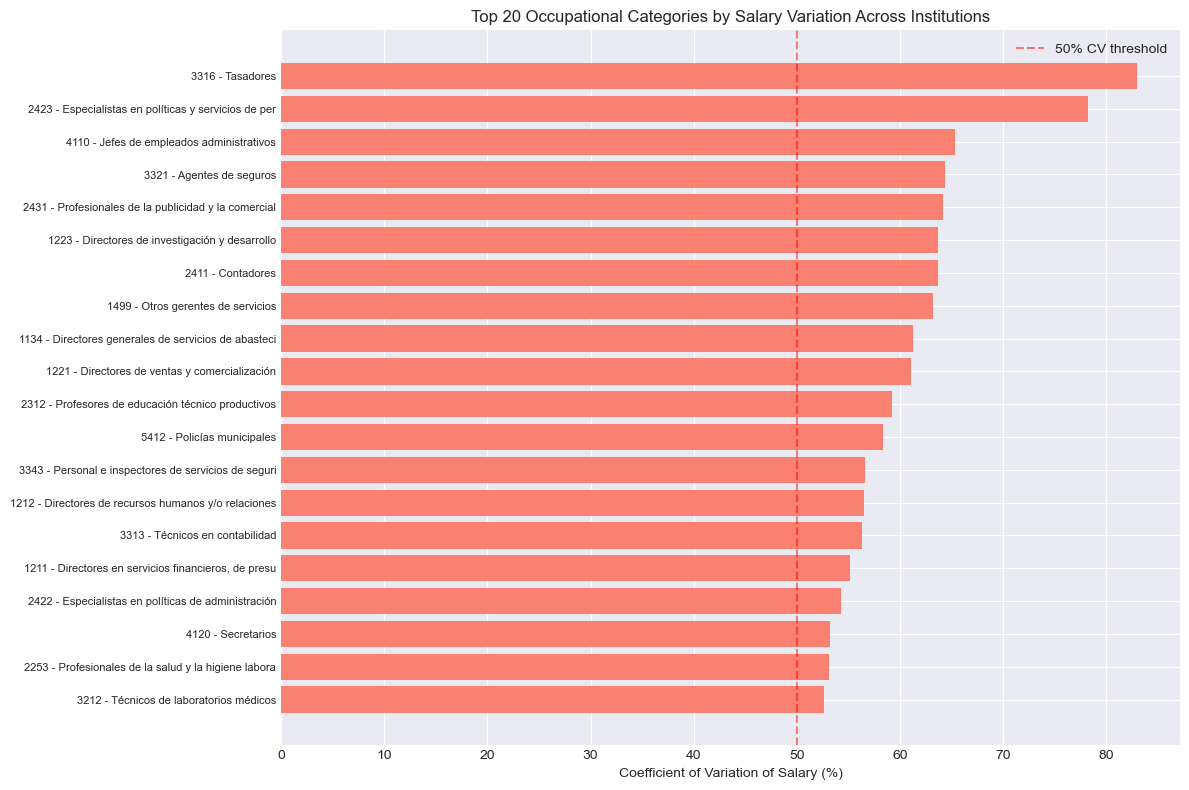

✓ Saved isco_salary_variation.csv


In [68]:
# Save
isco_analysis_sorted = isco_analysis[['isco_code', 'descripcion', 'postings', 
                                       'institutions', 'median_salary', 
                                       'avg_salary', 'std_salary', 'cv_salary']].sort_values('cv_salary', ascending=False)

isco_analysis_sorted.to_csv(output_dir / "isco_salary_variation.csv", index=False)

# Visualize top 20 by CV
top20 = isco_analysis_sorted.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20)), top20['cv_salary'], color='salmon')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f"{row['isco_code']} - {row['descripcion'][:45]}" 
                    for _, row in top20.iterrows()], fontsize=8)
ax.set_xlabel('Coefficient of Variation of Salary (%)')
ax.set_title('Top 20 Occupational Categories by Salary Variation Across Institutions')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% CV threshold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / "figures" / "isco_salary_cv.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved isco_salary_variation.csv")

In [69]:
def analyze_isco_salary_distribution(isco_code, df_salary, isco_labels):
    """For a given ISCO code, show salary distribution by institution."""
    
    label = isco_labels[isco_labels['codigo'] == str(isco_code)]['descripcion'].values[0]
    subset = df_salary[df_salary['isco_code'] == str(isco_code)][['institution', 'job_title', 'salary_amount']]
    
    inst_stats = (subset.groupby('institution')
                  .agg(
                      postings=('salary_amount', 'count'),
                      median_salary=('salary_amount', 'median'),
                      avg_salary=('salary_amount', 'mean'),
                      std_salary=('salary_amount', 'std'),
                      min_salary=('salary_amount', 'min'),
                      max_salary=('salary_amount', 'max')
                  )
                  .sort_values('median_salary', ascending=False)
                  .reset_index())
    
    overall_median = subset['salary_amount'].median()
    
    print(f"\nISCO {isco_code} — {label}")
    print(f"Overall median salary: S/. {overall_median:,.2f}")
    print(f"Institutions: {len(inst_stats)}, Postings: {len(subset)}")
    print(f"\nSalary by institution (sorted by median):")
    print(inst_stats.to_string(index=False))

analyze_isco_salary_distribution('3316', df_salary, isco_labels)


ISCO 3316 — Tasadores
Overall median salary: S/. 2,450.00
Institutions: 64, Postings: 86

Salary by institution (sorted by median):
                                                                                         institution  postings  median_salary  avg_salary  std_salary  min_salary  max_salary
                                                                       INSTITUTO PERUANO DEL DEPORTE         1       12000.00    12000.00         NaN    12000.00    12000.00
                                                           MINIST. DE TRABAJO Y PROMOCION DEL EMPLEO         5       12000.00    11600.00  547.722558    11000.00    12000.00
                                                                         MUNICIPALIDAD DE CHORRILLOS         1       10000.00    10000.00         NaN    10000.00    10000.00
                                                           MINISTERIO DE COMERCIO EXTERIOR Y TURISMO         1        8000.00     8000.00         NaN     8000.00     8000.

In [70]:
# Map nivel_gobierno to a readable label
nivel_map = {'E': 'Nacional', 'R': 'Regional', 'M': 'Municipal'}
df['nivel_label'] = df['nivel_gobierno'].map(nivel_map)

# For 3316, check if tier explains the variance
subset_3316 = df_salary[df_salary['isco_code'] == '3316'].copy()
subset_3316['nivel_label'] = subset_3316['nivel_gobierno'].map(nivel_map)

print("ISCO 3316 — Salary by government tier:")
print(subset_3316.groupby('nivel_label')['salary_amount']
      .agg(['count', 'median', 'mean', 'std'])
      .round(2))

ISCO 3316 — Salary by government tier:
             count   median     mean      std
nivel_label                                  
Municipal       44  2400.00  2337.38   632.63
Nacional        19  3000.00  5382.83  4228.14
Regional         7  2364.19  2931.56  2295.44


In [72]:
def flag_salary_anomalies(df_salary, isco_code, min_tier_n=5, min_inst_postings=2):
    """Flag institutions with anomalous salaries within their government tier."""
    
    subset = df_salary[df_salary['isco_code'] == str(isco_code)].copy()
    subset['nivel_label'] = subset['nivel_gobierno'].map({'E': 'Nacional', 'R': 'Regional', 'M': 'Municipal'})
    
    tier_stats = (subset.groupby('nivel_label')['salary_amount']
                  .agg(['mean', 'std', 'count'])
                  .rename(columns={'mean': 'tier_mean', 'std': 'tier_std', 'count': 'tier_n'}))
    
    subset = subset.merge(tier_stats, on='nivel_label')
    
    subset['z_score'] = np.where(
        (subset['tier_n'] >= min_tier_n) & (subset['tier_std'] > 0),
        (subset['salary_amount'] - subset['tier_mean']) / subset['tier_std'],
        np.nan
    )
    
    inst_summary = (subset.groupby(['institution', 'nivel_label'])
                    .agg(
                        postings=('salary_amount', 'count'),
                        median_salary=('salary_amount', 'median'),
                        avg_z_score=('z_score', 'mean')
                    )
                    .reset_index()
                    .sort_values('avg_z_score', ascending=False))
    
    # Only flag institutions with enough postings
    inst_summary = inst_summary[inst_summary['postings'] >= min_inst_postings]
    
    print(f"\nISCO {isco_code} — Anomalous institutions (|z| > 1.5, {min_inst_postings}+ postings):")
    flagged = inst_summary[inst_summary['avg_z_score'].abs() > 1.5]
    if len(flagged) == 0:
        print("No institutions flagged at this threshold.")
    else:
        print(flagged.to_string(index=False))
    
    return inst_summary

results_3316 = flag_salary_anomalies(df_salary, '3316')


ISCO 3316 — Anomalous institutions (|z| > 1.5, 2+ postings):
No institutions flagged at this threshold.


Total institutions: 743

Top 20 by posting volume:
                                                 institution nivel_label  postings
                                              PODER JUDICIAL    Nacional       647
          REGISTRO NACIONAL DE IDENTIFICACIÓN Y ESTADO CIVIL    Nacional       401
                         MINISTERIO PUBLICO-GERENCIA GENERAL   Municipal       337
                                     MINISTERIO DE EDUCACION    Nacional       273
                    INSTITUTO DE MANEJO DE AGUA Y MEDIO AMBI   Municipal       238
                               REGION CUSCO PLAN MERISS INKA   Municipal       198
                       MUNICIPALIDAD DISTRI. DE SAN JERONIMO   Municipal       195
                                  PROGRAMA NACIONAL CUNA MAS    Nacional       170
                      MUNICIPALIDAD PROVINCIAL LEONCIO PRADO   Municipal       156
                    MUNICIPALIDAD PROVINCIAL DE CHUMBIVILCAS   Municipal       144
                      MUNICIPALIDAD 

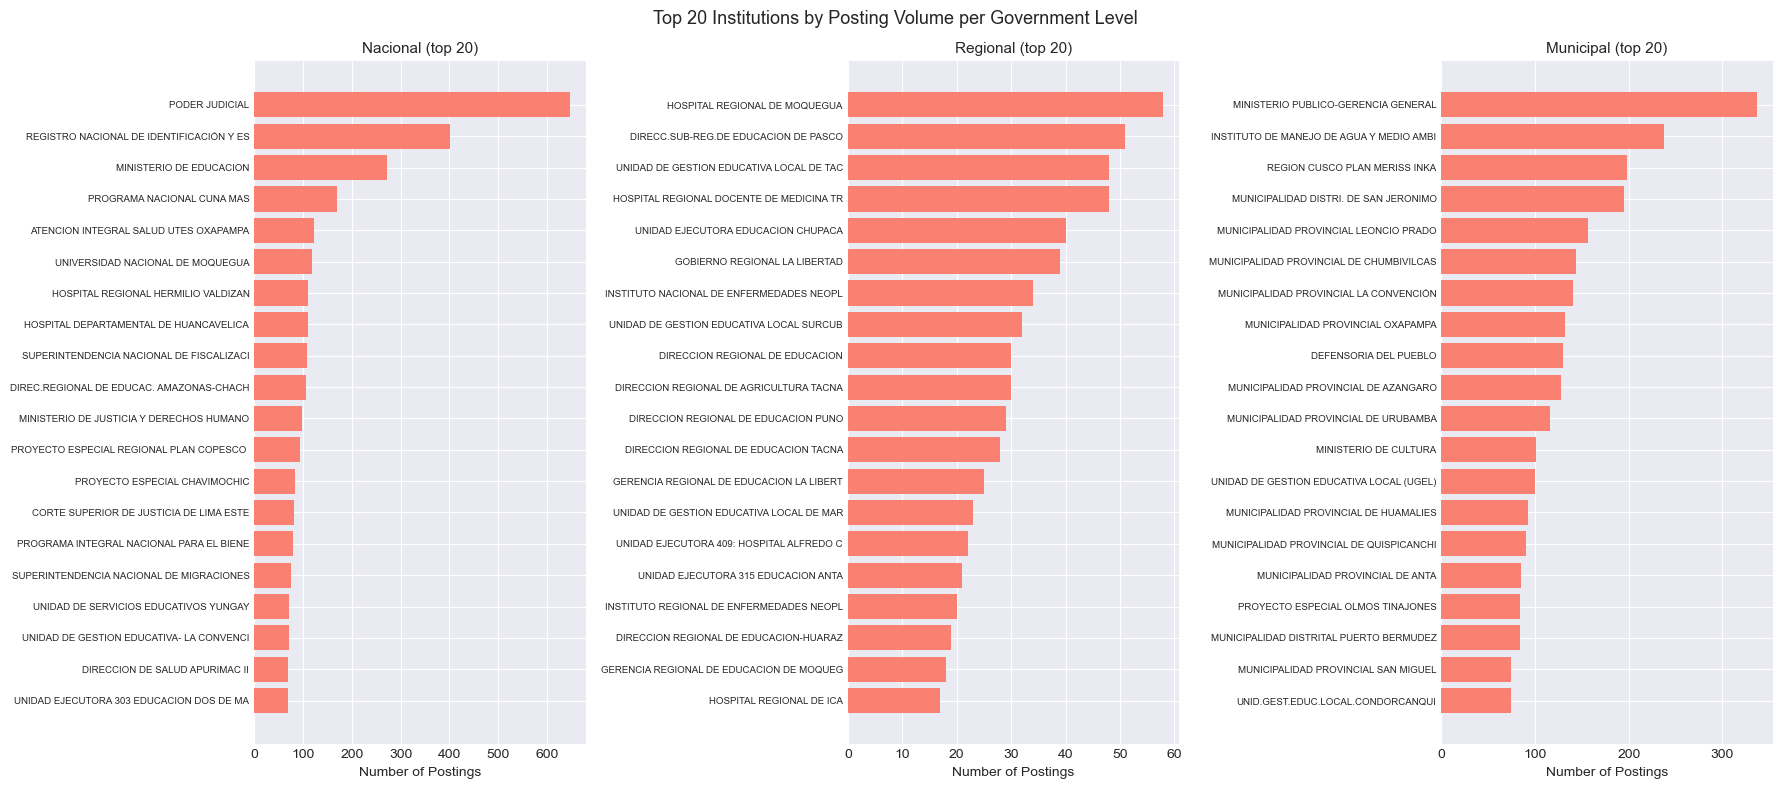

In [74]:
inst_postings = (df.groupby(['institution', 'nivel_label'])
                 .size()
                 .reset_index(name='postings')
                 .sort_values('postings', ascending=False))

print(f"Total institutions: {inst_postings['institution'].nunique()}")
print(f"\nTop 20 by posting volume:")
print(inst_postings.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, nivel in zip(axes, ['Nacional', 'Regional', 'Municipal']):
    subset = inst_postings[inst_postings['nivel_label'] == nivel].sort_values('postings', ascending=False)
    top_n = subset.head(20)
    
    ax.barh(range(len(top_n)), top_n['postings'], color='salmon')
    ax.set_yticks(range(len(top_n)))
    ax.set_yticklabels([t[:40] for t in top_n['institution']], fontsize=7)
    ax.set_title(f'{nivel} (top 20)', fontsize=11)
    ax.set_xlabel('Number of Postings')
    ax.invert_yaxis()

plt.suptitle('Top 20 Institutions by Posting Volume per Government Level', fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "figures" / "institution_posting_volume.png", dpi=300, bbox_inches='tight')
plt.show()

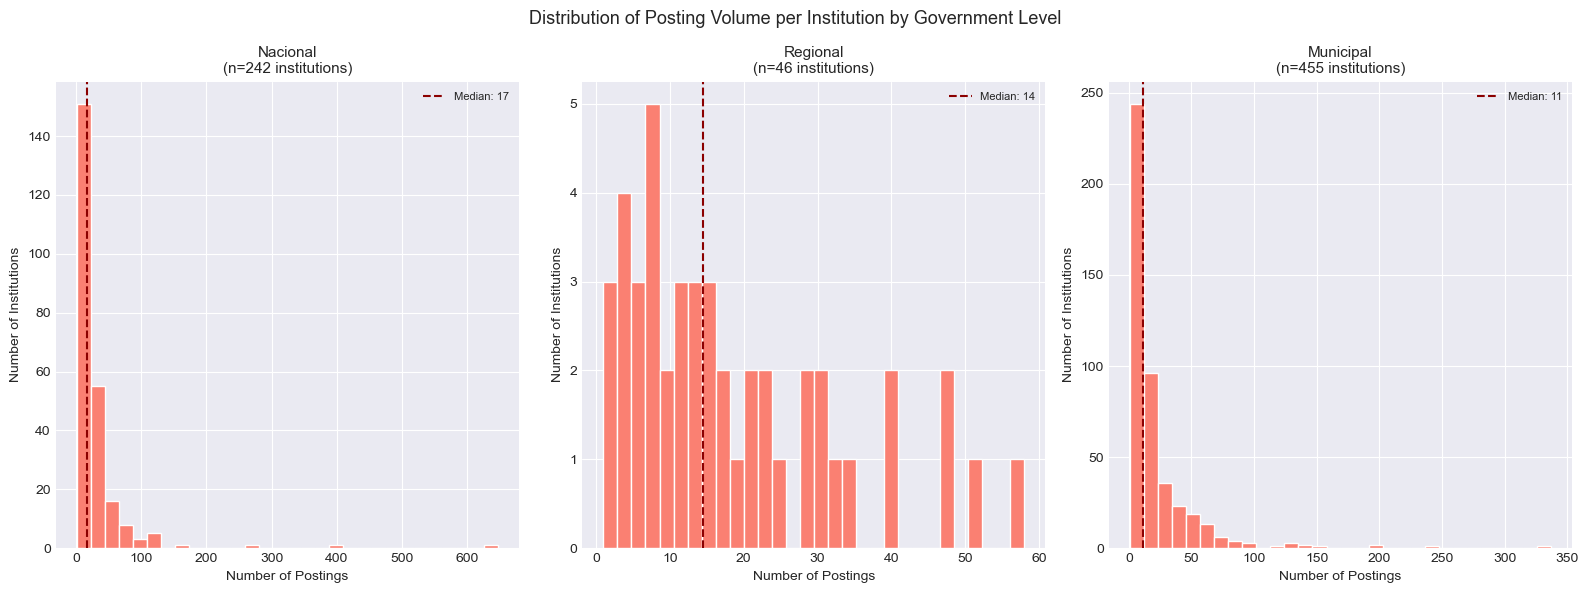

Posting volume summary by government level:
             count  mean   std  min  25%   50%   75%    max
nivel_label                                                
Municipal    455.0  21.4  31.9  1.0  5.0  11.0  25.0  337.0
Nacional     242.0  29.5  55.4  1.0  7.0  17.0  34.0  647.0
Regional      46.0  18.4  14.5  1.0  7.0  14.5  27.2   58.0


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, nivel in zip(axes, ['Nacional', 'Regional', 'Municipal']):
    subset = inst_postings[inst_postings['nivel_label'] == nivel]['postings']
    
    ax.hist(subset, bins=30, color='salmon', edgecolor='white')
    ax.set_title(f'{nivel}\n(n={len(subset)} institutions)', fontsize=11)
    ax.set_xlabel('Number of Postings')
    ax.set_ylabel('Number of Institutions')
    
    # Annotate with median
    ax.axvline(subset.median(), color='darkred', linestyle='--', linewidth=1.5, 
               label=f'Median: {subset.median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Posting Volume per Institution by Government Level', fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "figures" / "institution_posting_frequency.png", dpi=300, bbox_inches='tight')
plt.show()

# Summary stats per level
print("Posting volume summary by government level:")
print(inst_postings.groupby('nivel_label')['postings']
      .describe().round(1).to_string())

In [76]:
reniec = df[
    (df['institution'] == 'REGISTRO NACIONAL DE IDENTIFICACIÓN Y ESTADO CIVIL') &
    (df['job_title'] == 'ASISTENTE REGISTRAL')
].copy()

print(f"Total postings: {len(reniec)}")
print(f"Date range: {reniec['posting_start_date'].min().date()} to {reniec['posting_start_date'].max().date()}")

# Which columns vary?
print("\n=== REQUIREMENT FIELDS ===")
key_fields = ['salary_amount', 'number_of_vacancies', 'contract_type', 
              'contract_regime', 'contract_temporal_nature',
              'experience_general_years', 'experience_specific_years',
              'academic_profile', 'specialization', 'knowledge', 'competencies']

for col in key_fields:
    if col in reniec.columns:
        n_unique = reniec[col].nunique()
        print(f"{col}: {n_unique} unique values")

Total postings: 245
Date range: 2026-02-02 to 2026-02-02

=== REQUIREMENT FIELDS ===
salary_amount: 1 unique values
number_of_vacancies: 11 unique values
contract_type: 1 unique values
contract_regime: 1 unique values
contract_temporal_nature: 1 unique values
experience_general_years: 0 unique values
experience_specific_years: 0 unique values
academic_profile: 11 unique values
specialization: 8 unique values
knowledge: 4 unique values
competencies: 2 unique values


In [77]:
print("=== SALARY ===")
print(reniec['salary_amount'].value_counts())

print("\n=== VACANCIES ===")
print(reniec['number_of_vacancies'].describe())

print("\n=== ACADEMIC PROFILE ===")
print(reniec['academic_profile'].value_counts())

print("\n=== SPECIALIZATION ===")
print(reniec['specialization'].value_counts())

print("\n=== KNOWLEDGE ===")
print(reniec['knowledge'].value_counts())

print("\n=== COMPETENCIES ===")
print(reniec['competencies'].value_counts())

=== SALARY ===
salary_amount
2700.0    245
Name: count, dtype: int64

=== VACANCIES ===
count    245.000000
mean       1.959184
std        1.762068
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       12.000000
Name: number_of_vacancies, dtype: float64

=== ACADEMIC PROFILE ===
academic_profile
TÉCNICO SUPERIOR PROFESIONAL EGRESADO EN ADMINISTRACIÓN O, CONTABILIDAD O, EDUCACIÓN O, COMPUTACIÓN; O ESTUDIANTE UNIVERSITARIO DE ÚLTIMO CICLO EN DERECHO O, ADMINISTRACIÓN O, CONTABILIDAD O, ECONOMÍA O, EDUCACIÓN O, COMPUTACIÓN O, CIENCIAS SOCIALES O INGENIERÍA. (INDISPENSABLE)    97
TÉCNICO SUPERIOR PROFESIONAL EGRESADO EN ADMINISTRACIÓN O, CONTABILIDAD O, EDUCACIÓN O, COMPUTACIÓN; O ESTUDIANTE UNIVERSITARIO DE ÚLTIMO CICLO EN DERECHO O, ADMINISTRACIÓN O, CONTABILIDAD O, ECONOMÍA O, EDUCACIÓN O, COMPUTACIÓN O, CIENCIAS SOCIALES O INGENIERÍA.INDISPENSABLE.      38
TÉCNICO PROFESIONAL EGRESADO EN ADMINISTRACIÓN,CONTABILIDAD,EDUCACIÓN O COMPUTACIÓN E INFORMÁTI

In [78]:
import re

def normalize_text(text):
    """Strip punctuation variations to compare substantive content."""
    if pd.isna(text):
        return None
    text = text.upper().strip()
    text = re.sub(r'[^\w\s]', ' ', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text)       # collapse whitespace
    return text.strip()

reniec['academic_profile_norm'] = reniec['academic_profile'].apply(normalize_text)
reniec['specialization_norm'] = reniec['specialization'].apply(normalize_text)
reniec['knowledge_norm'] = reniec['knowledge'].apply(normalize_text)
reniec['competencies_norm'] = reniec['competencies'].apply(normalize_text)

print("After normalization:")
print(f"academic_profile unique: {reniec['academic_profile_norm'].nunique()}")
print(f"specialization unique:   {reniec['specialization_norm'].nunique()}")
print(f"knowledge unique:        {reniec['knowledge_norm'].nunique()}")
print(f"competencies unique:     {reniec['competencies_norm'].nunique()}")

After normalization:
academic_profile unique: 3
specialization unique:   2
knowledge unique:        3
competencies unique:     1


In [79]:
print("=== ACADEMIC PROFILE (normalized) ===")
print(reniec['academic_profile_norm'].value_counts())

print("\n=== SPECIALIZATION (normalized) ===")
print(reniec['specialization_norm'].value_counts())

print("\n=== KNOWLEDGE (normalized) ===")
print(reniec['knowledge_norm'].value_counts())

=== ACADEMIC PROFILE (normalized) ===
academic_profile_norm
TÉCNICO SUPERIOR PROFESIONAL EGRESADO EN ADMINISTRACIÓN O CONTABILIDAD O EDUCACIÓN O COMPUTACIÓN O ESTUDIANTE UNIVERSITARIO DE ÚLTIMO CICLO EN DERECHO O ADMINISTRACIÓN O CONTABILIDAD O ECONOMÍA O EDUCACIÓN O COMPUTACIÓN O CIENCIAS SOCIALES O INGENIERÍA INDISPENSABLE    218
TÉCNICO PROFESIONAL EGRESADO EN ADMINISTRACIÓN CONTABILIDAD EDUCACIÓN O COMPUTACIÓN E INFORMÁTICA O ESTUDIANTE UNIVERSITARIO DE ÚLTIMO CICLO EN DERECHO ADMINISTRACIÓN CONTABILIDAD ECONOMÍA EDUCACIÓN COMPUTACIÓN CIENCIAS SOCIALES E INGENIERÍA INDISPENSABLE                26
TÉCNICO PROFESIONAL EGRESADO ENADMINISTRACIÓN CONTABILIDAD EDUCACIÓN O COMPUTACIÓN E INFORMÁTICA O ESTUDIANTE UNIVERSITARIO DE ÚLTIMO CICLO EN DERECHO ADMINISTRACIÓN CONTABILIDAD ECONOMÍA EDUCACIÓN COMPUTACIÓN CIENCIAS SOCIALES E INGENIERÍA INDISPENSABLE                  1
Name: count, dtype: int64

=== SPECIALIZATION (normalized) ===
specialization_norm
CURSO DE 12 HORAS ACUMULADAS EN ATE

In [80]:
# Do the two variants correspond to different locations?
reniec['variant'] = (reniec['academic_profile_norm']
                     .str.startswith('TÉCNICO SUPERIOR'))
reniec['variant'] = reniec['variant'].map({True: 'SUPERIOR', False: 'PROFESIONAL'})

print("Variant distribution:")
print(reniec['variant'].value_counts())

print("\nVariant by posting date (any temporal pattern?):")
print(reniec.groupby(['variant', reniec['posting_start_date'].dt.date]).size())

# Check if they differ by number of vacancies
print("\nVacancies by variant:")
print(reniec.groupby('variant')['number_of_vacancies']
      .agg(['count', 'mean', 'median', 'sum']))

Variant distribution:
variant
SUPERIOR       218
PROFESIONAL     27
Name: count, dtype: int64

Variant by posting date (any temporal pattern?):
variant      posting_start_date
PROFESIONAL  2026-02-02             27
SUPERIOR     2026-02-02            218
dtype: int64

Vacancies by variant:
             count      mean  median  sum
variant                                  
PROFESIONAL     27  1.703704     1.0   46
SUPERIOR       218  1.990826     1.0  434


In [81]:
# Find institution-job pairs with postings on multiple distinct dates
multi_date = (df.groupby(['institution', 'job_title'])
              .agg(
                  total_postings=('posting_unique_id', 'count'),
                  distinct_dates=('posting_start_date', 'nunique'),
                  first_posting=('posting_start_date', 'min'),
                  last_posting=('posting_start_date', 'max')
              )
              .reset_index())

# Filter: same job posted on 3+ distinct dates
multi_date = multi_date[multi_date['distinct_dates'] >= 3].sort_values('distinct_dates', ascending=False)

print(f"Institution-job pairs posted on 3+ distinct dates: {len(multi_date)}")
print(f"\nTop 30:")
print(multi_date.head(30).to_string(index=False))

Institution-job pairs posted on 3+ distinct dates: 260

Top 30:
                              institution                                              job_title  total_postings  distinct_dates first_posting last_posting
                           PODER JUDICIAL                       ESPECIALISTA JUDICIAL DE JUZGADO              53              32    2025-12-15   2026-04-01
                           PODER JUDICIAL                                    SECRETARIO JUDICIAL              64              29    2025-12-12   2026-03-31
                           PODER JUDICIAL                     ESPECIALISTA JUDICIAL DE AUDIENCIA              42              28    2025-12-15   2026-03-31
                           PODER JUDICIAL                                     ASISTENTE JUDICIAL              53              27    2025-12-16   2026-03-27
                           PODER JUDICIAL                               ASISTENTE JURISDICCIONAL              24              17    2025-12-22   2026-03-31


In [82]:
pj_sec = df[
    (df['institution'] == 'PODER JUDICIAL') &
    (df['job_title'] == 'SECRETARIO JUDICIAL')
].copy()

pj_sec['posting_start_date'] = pd.to_datetime(pj_sec['posting_start_date'])

# Normalize text fields
for col in ['academic_profile', 'specialization', 'knowledge', 'competencies']:
    pj_sec[f'{col}_norm'] = pj_sec[col].apply(normalize_text)

print(f"Total postings: {len(pj_sec)}")
print(f"Date range: {pj_sec['posting_start_date'].min().date()} to {pj_sec['posting_start_date'].max().date()}")
print(f"Distinct dates: {pj_sec['posting_start_date'].nunique()}")

print("\n=== REQUIREMENT STABILITY ===")
key_fields = ['salary_amount', 'number_of_vacancies', 'contract_regime',
              'contract_temporal_nature', 'experience_general_years',
              'experience_specific_years', 'academic_profile_norm',
              'specialization_norm', 'knowledge_norm', 'competencies_norm']

for col in key_fields:
    n_unique = pj_sec[col].nunique()
    print(f"{col}: {n_unique} unique values")

Total postings: 64
Date range: 2025-12-12 to 2026-03-31
Distinct dates: 29

=== REQUIREMENT STABILITY ===
salary_amount: 3 unique values
number_of_vacancies: 3 unique values
contract_regime: 2 unique values
contract_temporal_nature: 2 unique values
experience_general_years: 2 unique values
experience_specific_years: 2 unique values
academic_profile_norm: 32 unique values
specialization_norm: 46 unique values
knowledge_norm: 26 unique values
competencies_norm: 24 unique values


In [83]:
print("=== SALARY VALUES ===")
print(pj_sec['salary_amount'].value_counts())

print("\n=== CONTRACT REGIME ===")
print(pj_sec['contract_regime'].value_counts())

print("\n=== CONTRACT TEMPORAL NATURE ===")
print(pj_sec['contract_temporal_nature'].value_counts())

print("\n=== EXPERIENCE GENERAL YEARS ===")
print(pj_sec['experience_general_years'].value_counts())

print("\n=== EXPERIENCE SPECIFIC YEARS ===")
print(pj_sec['experience_specific_years'].value_counts())

print("\n=== TOP ACADEMIC PROFILES ===")
print(pj_sec['academic_profile_norm'].value_counts().head(10))

print("\n=== TOP SPECIALIZATIONS ===")
print(pj_sec['specialization_norm'].value_counts().head(10))

=== SALARY VALUES ===
salary_amount
5670.0    32
2972.0    19
4750.0    13
Name: count, dtype: int64

=== CONTRACT REGIME ===
contract_regime
D.LEG 728     32
D.LEG 1057    32
Name: count, dtype: int64

=== CONTRACT TEMPORAL NATURE ===
contract_temporal_nature
PERMANENT    32
TEMPORARY    32
Name: count, dtype: int64

=== EXPERIENCE GENERAL YEARS ===
experience_general_years
2.0    4
1.0    1
Name: count, dtype: int64

=== EXPERIENCE SPECIFIC YEARS ===
experience_specific_years
2.0    2
1.0    1
Name: count, dtype: int64

=== TOP ACADEMIC PROFILES ===
academic_profile_norm
TÍTULO PROFESIONAL UNIVERSITARIO EN DERECHO CON COLEGIATURA VIGENTE Y HABILITADO A                                                                     8
OBLIGATORIO TÍTULO PROFESIONAL EN DERECHO CON COLEGIATURA Y HABILITACIÓN PROFESIONAL VIGENTE ACREDITADO                                                7
OBLIGATORIO TÍTULO PROFESIONAL EN DERECHO COLEGIATURA Y HABILITACIÓN PROFESIONAL VIGENTE                          

In [84]:
# Are the two contract regimes posted on different dates or interleaved?
regime_dates = pj_sec.groupby(['contract_regime', 'contract_temporal_nature', 'salary_amount']).agg(
    postings=('posting_unique_id', 'count'),
    first_date=('posting_start_date', 'min'),
    last_date=('posting_start_date', 'max'),
    distinct_dates=('posting_start_date', 'nunique')
).reset_index()

print("=== CONTRACT REGIME x SALARY x DATES ===")
print(regime_dates.to_string(index=False))

# Are specializations consistent within each regime?
print("\n=== SPECIALIZATION UNIQUE VALUES BY REGIME ===")
for regime in pj_sec['contract_regime'].unique():
    subset = pj_sec[pj_sec['contract_regime'] == regime]
    print(f"\n{regime} ({len(subset)} postings):")
    print(f"  Unique specializations: {subset['specialization_norm'].nunique()}")
    print(f"  Unique academic profiles: {subset['academic_profile_norm'].nunique()}")
    print(f"  Salary values: {subset['salary_amount'].unique()}")

=== CONTRACT REGIME x SALARY x DATES ===
contract_regime contract_temporal_nature  salary_amount  postings first_date  last_date  distinct_dates
     D.LEG 1057                TEMPORARY         2972.0        19 2025-12-12 2026-03-24              13
     D.LEG 1057                TEMPORARY         4750.0        13 2025-12-15 2026-03-25              12
      D.LEG 728                PERMANENT         5670.0        32 2026-01-08 2026-03-31              14

=== SPECIALIZATION UNIQUE VALUES BY REGIME ===

D.LEG 728 (32 postings):
  Unique specializations: 23
  Unique academic profiles: 12
  Salary values: [5670.]

D.LEG 1057 (32 postings):
  Unique specializations: 23
  Unique academic profiles: 22
  Salary values: [2972. 4750.]


In [85]:
# Test: does specialization cluster into coherent groups?
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Get non-null specializations
specs = pj_sec['specialization_norm'].dropna().tolist()

vectorizer = TfidfVectorizer(max_features=50)
X = vectorizer.fit_transform(specs)

# Try 4-6 clusters
from sklearn.metrics import silhouette_score

for k in range(3, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}: silhouette score={score:.3f}")

k=3: silhouette score=0.203
k=4: silhouette score=0.243
k=5: silhouette score=0.276
k=6: silhouette score=0.289
